# Interpolating Missing Data Based on Monitor Associations

## Load the libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

import glob

from scipy.stats import linregress

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.model_selection import RandomizedSearchCV, train_test_split, KFold

## Load + Merge the hourly data

This section loads the hourly datasets for PM 2.5, temperature, and relative humidity from the QuantAQ network. The goal is to combine these separate files into unified, continuous datasets for each variable and then merge them together by monitor, date, and hour to form a complete record of pollutant and weather measurements.

In [2]:
# path to data
data_dir = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/"

# PM 2.5 hourly
hourly_pm25_20230815_20260315 = pd.read_csv(data_dir + "pm/GRIMM_calibrated_pm_summaries/hourly_pm25_modulair_full_calibrated_gmr_20231024-20260315.csv")

## old version (non grimm calibrated) had mean_pm25 for the hourly value. adding that syntax here so the code below runs with same vars
hourly_pm25_20230815_20260315["mean_pm25"] = hourly_pm25_20230815_20260315["pm25_fem_gmr"]

# PM 1 hourly
hourly_pm1_20230815_20240816 = pd.read_csv(data_dir + "pm/summarized/pm1_community_hourly_20230815_20240816.csv")
hourly_pm1_20240815_20241031 = pd.read_csv(data_dir + "pm/summarized/pm1_community_hourly_20240815_20241031.csv")
hourly_pm1_20241031_20250901 = pd.read_csv(data_dir + "pm/summarized/pm1_community_hourly_20241031_20250901.csv")
hourly_pm1_20250831_20260315 = pd.read_csv(data_dir + "pm/summarized/pm1_community_hourly_20250831_20260315.csv")

# PM 10 hourly 
hourly_pm10_20230815_20260315 = pd.read_csv(data_dir + "pm/GRIMM_calibrated_pm_summaries/hourly_pm10_modulair_full_calibrated_gmr_20231024-20260315.csv")

## old version (non grimm calibrated) had mean_pm10 for the hourly value. adding that syntax here so the code below runs with same vars
hourly_pm10_20230815_20260315["mean_pm10"] = hourly_pm10_20230815_20260315["pm10_fem_gmr"]


# temperature hourly
hourly_temp_20230815_20240820 = pd.read_csv(data_dir + "weather/summarized/temp_hourly_20230815-20240820.csv")
hourly_temp_20240816_20241031 = pd.read_csv(data_dir + "weather/summarized/temp_hourly_20240816-20241031.csv")
hourly_temp_20241031_20250901 = pd.read_csv(data_dir + "weather/summarized/temp_hourly_20241031-20250901.csv")
hourly_temp_20250831_20260315 = pd.read_csv(data_dir + "weather/summarized/temp_hourly_20250831-20260315.csv")

# relative humidity hourly 
hourly_rh_20230815_20240820 = pd.read_csv(data_dir + "weather/summarized/rh_hourly_20230815-20240820.csv")
hourly_rh_20240816_20241031 = pd.read_csv(data_dir + "weather/summarized/rh_hourly_20240816-20241031.csv")
hourly_rh_20241031_20250901 = pd.read_csv(data_dir + "weather/summarized/rh_hourly_20241031-20250901.csv")
hourly_rh_20250831_20260315 = pd.read_csv(data_dir + "weather/summarized/rh_hourly_20250831-20260315.csv")



# Combine each date range for weather / PM variables 
hourly_pm25_full = pd.concat([hourly_pm25_20230815_20260315], ignore_index=True)
hourly_pm1_full = pd.concat([hourly_pm1_20230815_20240816, hourly_pm1_20240815_20241031, hourly_pm1_20241031_20250901,hourly_pm1_20250831_20260315], ignore_index=True)
hourly_pm10_full = pd.concat([hourly_pm10_20230815_20260315], ignore_index=True)
hourly_temp_full = pd.concat([hourly_temp_20230815_20240820, hourly_temp_20240816_20241031, hourly_temp_20241031_20250901,hourly_temp_20250831_20260315], ignore_index=True)
hourly_rh_full = pd.concat([hourly_rh_20230815_20240820, hourly_rh_20240816_20241031,hourly_rh_20241031_20250901, hourly_rh_20250831_20260315], ignore_index=True)

# rename vars so distinct column names when joining full data 
hourly_pm25_full = hourly_pm25_full.rename(
    columns={
        "n_minute_obs": "n_minute_obs_pm25",
        "n_active": "n_active_pm25"
    }
)

hourly_pm1_full = hourly_pm1_full.rename(
    columns={
        "n_minute_obs": "n_minute_obs_pm1",
        "n_active": "n_active_pm1"
    }
)

hourly_pm10_full = hourly_pm10_full.rename(
    columns={
        "n_minute_obs": "n_minute_obs_pm10",
        "n_active": "n_active_pm10"
    }
)

hourly_temp_full = hourly_temp_full.rename(
    columns={
        "n_minute_obs": "n_minute_obs_temp",
        "n_active": "n_active_temp"
    }
)


hourly_rh_full = hourly_rh_full.rename(
    columns={
        "n_minute_obs": "n_minute_obs_rh",
        "n_active": "n_active_rh"
    }
)


# ---- Check for duplicates before joining ----
dups_pm25 = hourly_pm25_full.duplicated(subset=["monitor", "date", "hour"]).sum()
dups_pm1 = hourly_pm1_full.duplicated(subset=["monitor", "date", "hour"]).sum()
dups_pm10 = hourly_pm10_full.duplicated(subset=["monitor", "date", "hour"]).sum()
dups_temp = hourly_temp_full.duplicated(subset=["monitor", "date", "hour"]).sum()
dups_rh = hourly_rh_full.duplicated(subset=["monitor", "date", "hour"]).sum()

print(f"PM 25 duplicates: {dups_pm25}")
print(f"PM 1 duplicates: {dups_pm1}")
print(f"PM 10 duplicates: {dups_pm10}")
print(f"Temp duplicates: {dups_temp}")
print(f"RH duplicates: {dups_rh}")


# ---- Remove duplicates before joining ----
hourly_pm25_full = hourly_pm25_full.drop_duplicates(subset=["monitor", "date", "hour"], keep="first")
hourly_pm1_full  = hourly_pm1_full.drop_duplicates(subset=["monitor", "date", "hour"], keep="first")
hourly_pm10_full = hourly_pm10_full.drop_duplicates(subset=["monitor", "date", "hour"], keep="first")
hourly_temp_full = hourly_temp_full.drop_duplicates(subset=["monitor", "date", "hour"], keep="first")
hourly_rh_full   = hourly_rh_full.drop_duplicates(subset=["monitor", "date", "hour"], keep="first")

hourly_pm25_full


PM 25 duplicates: 12262
PM 1 duplicates: 5884
PM 10 duplicates: 12310
Temp duplicates: 5844
RH duplicates: 5844


,monitor,date,hour,mod_pm25,mod_temp,mod_rh,date_hour,sin_hour,cos_hour,month,season_binary,pm25_fem_gmr,delta_gmr,ratio_gmr,mean_pm25
0,MOD-00077,2024-09-03,16.0,65.614000,35.835000,46.395000,2024-09-03 16:00:00+00:00,-0.866025,-5.000000e-01,9,0,24.579372,-41.034628,0.374606,24.579372
1,MOD-00077,2024-09-03,17.0,102.075000,32.908333,53.998333,2024-09-03 17:00:00+00:00,-0.965926,-2.588190e-01,9,0,35.716478,-66.358522,0.349904,35.716478
2,MOD-00077,2024-09-03,18.0,153.113500,30.603333,62.325000,2024-09-03 18:00:00+00:00,-1.000000,-1.836970e-16,9,0,51.661698,-101.451802,0.337408,51.661698
3,MOD-00077,2024-09-03,19.0,151.813000,29.363333,68.226667,2024-09-03 19:00:00+00:00,-0.965926,2.588190e-01,9,0,52.138254,-99.674746,0.343437,52.138254
4,MOD-00077,2024-09-03,20.0,82.144833,28.330000,72.103333,2024-09-03 20:00:00+00:00,-0.866025,5.000000e-01,9,0,32.040908,-50.103925,0.390054,32.040908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715122,MOD-PM-01093,2026-03-12,5.0,7.015866,27.834821,71.684643,2026-03-12 05:00:00+00:00,0.965926,2.588190e-01,3,0,12.028235,5.012369,1.714433,12.028235
715123,MOD-PM-01093,2026-03-13,7.0,5.870465,30.366604,65.292075,2026-03-13 07:00:00+00:00,0.965926,-2.588190e-01,3,0,10.510674,4.640210,1.790433,10.510674
715124,MOD-PM-01093,2026-03-13,8.0,8.969727,32.395357,59.195893,2026-03-13 08:00:00+00:00,0.866025,-5.000000e-01,3,0,10.731467,1.761740,1.196410,10.731467
715125,MOD-PM-01093,2026-03-13,9.0,8.140360,34.749322,52.739661,2026-03-13 09:00:00+00:00,0.707107,-7.071068e-01,3,0,9.829280,1.688920,1.207475,9.829280


In [3]:
## Merge the PM and weather data 
hourly_full = (
    hourly_pm25_full # start with hourly pm 2.5
    .merge(
        hourly_pm1_full, # add pm 1
        on = ["monitor", "date", "hour"],
        how = "outer"
    )
    .merge(
        hourly_pm10_full, # add pm 10
        on = ["monitor", "date", "hour"],
        how = "outer"
    )
    .merge(
        hourly_temp_full, # add hourly temp
        on=["monitor", "date", "hour"],
        how="outer"
    )
    .merge(
        hourly_rh_full, # add hourly RH 
        on=["monitor", "date", "hour"],
        how="outer"
    )
)

## drop NA hours (need to adjust weather data cleaning so midnight counts as hour 0)
hourly_full = hourly_full.dropna(subset=["hour"])

# Normalize identifiers 
hourly_full["monitor"] = (
    hourly_full["monitor"].astype(str)
      .str.strip()
      .str.upper()
      .str.replace(r'[\u2010\u2011\u2012\u2013\u2014\u2015]', '-', regex=True)
      .str.replace(r'\s+', '', regex=True)
)


# ensure date formats work 
hourly_full["date"] = pd.to_datetime(hourly_full["date"])

hourly_full["date"] = pd.to_datetime(hourly_full["date"]).dt.normalize()

hourly_full["timestamp"] = hourly_full["date"] + pd.to_timedelta(hourly_full["hour"], unit="h")

# check out data
print(hourly_full.head)
print(hourly_full["monitor"].nunique())

<bound method NDFrame.head of               monitor       date  hour  mod_pm25  mod_temp_x  mod_rh_x  \
0           MOD-00077 2024-08-15   0.0       NaN         NaN       NaN   
1           MOD-00077 2024-08-15   1.0       NaN         NaN       NaN   
2           MOD-00077 2024-08-15   2.0       NaN         NaN       NaN   
3           MOD-00077 2024-08-15   3.0       NaN         NaN       NaN   
4           MOD-00077 2024-08-15   4.0       NaN         NaN       NaN   
...               ...        ...   ...       ...         ...       ...   
1281693  MOD-PM-01093 2026-03-15  20.0       NaN         NaN       NaN   
1281694  MOD-PM-01093 2026-03-15  21.0       NaN         NaN       NaN   
1281695  MOD-PM-01093 2026-03-15  22.0       NaN         NaN       NaN   
1281696  MOD-PM-01093 2026-03-15  23.0       NaN         NaN       NaN   
1281697  MOD-PM-01093 2026-03-16   0.0       NaN         NaN       NaN   

        date_hour_x  sin_hour_x  cos_hour_x  month_x  ...  mean_pm10  \
0        

## Examine missingness

This section evaluates data completeness across monitors and days to understand coverage and identify patterns of missing PM 2.5 data. It calculates the proportion of valid hourly PM₂.₅ readings per monitor-day (out of 24 expected hours) and visualizes the results as a heatmap of daily completeness.

In [4]:

# compute daily completeness (hours with valid mean_pm25 / expected 24)
daily_counts = (
    hourly_full
    .dropna(subset=["mean_pm25"])  # only keep rows where PM2.5 is not missing
    .groupby(["monitor", "date"], as_index=False)
    .agg(n_hours=("hour", "nunique"))
)
daily_counts["pct_complete"] = daily_counts["n_hours"] / 24

In [5]:
daily_counts.info()
daily_counts.head()

# reshape data wide so each row is monitor and each column is date with the percent complete for the date
pivot_df = daily_counts.pivot(index="monitor", columns="date", values="pct_complete")

print(pivot_df.shape)
print(pivot_df.index.nunique(), "unique monitors in pivot table")
print(pivot_df.columns.nunique(), "unique dates in pivot table")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28407 entries, 0 to 28406
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   monitor       28407 non-null  object        
 1   date          28407 non-null  datetime64[ns]
 2   n_hours       28407 non-null  int64         
 3   pct_complete  28407 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 887.8+ KB
(66, 944)
66 unique monitors in pivot table
944 unique dates in pivot table


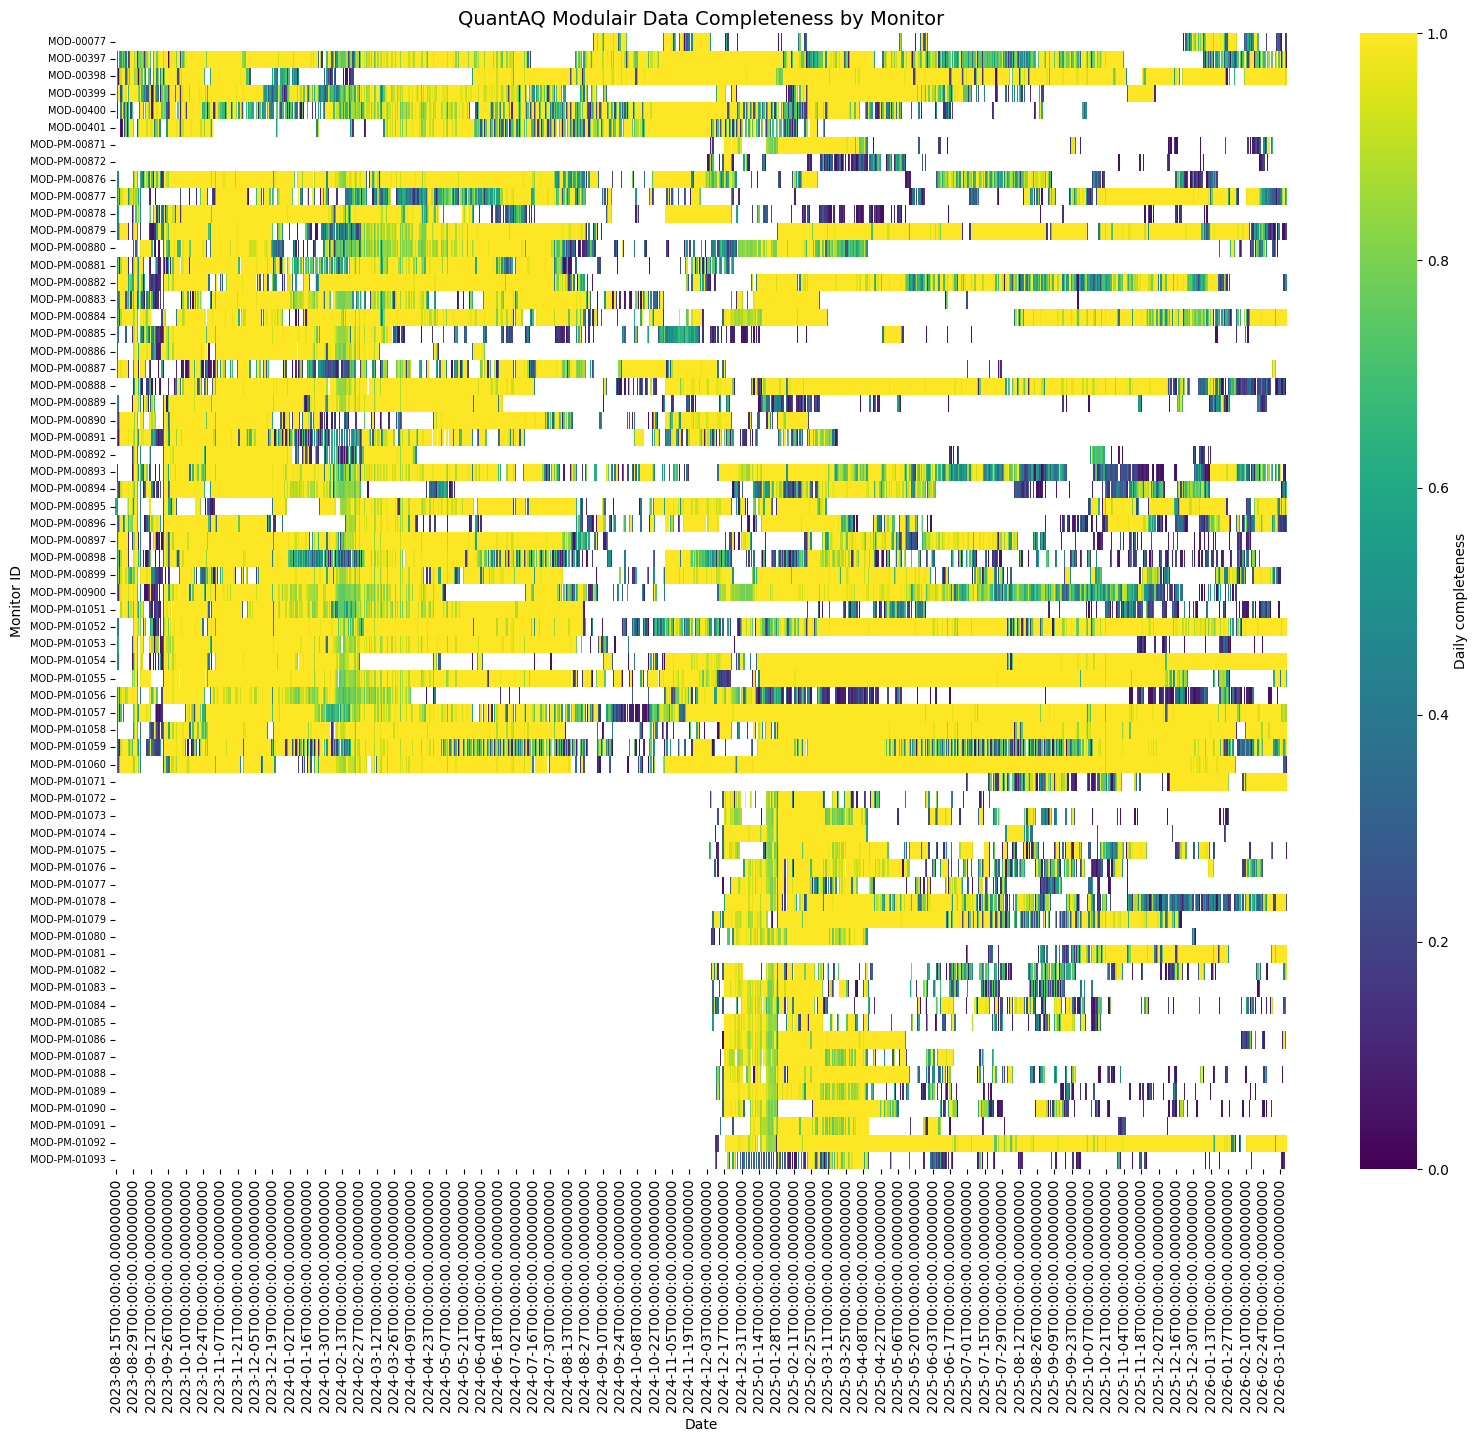

In [6]:
order = list(pivot_df.index)  # keep all 66 monitors
fig_height = max(12, len(order) * 0.22)

plt.figure(figsize=(16, fig_height))
ax = sns.heatmap(
    pivot_df.loc[order],
    cmap="viridis",
    vmin=0, vmax=1,
    cbar_kws={"label": "Daily completeness"},
    mask=pivot_df.loc[order] == 0  # hide background when completeness = 0
)

# show all y labels
ax.set_yticks(np.arange(len(order)) + 0.5)
ax.set_yticklabels(order, fontsize=7, rotation=0)

# style tweaks
ax.set_facecolor("white")  # make background white for masked cells
plt.title("QuantAQ Modulair Data Completeness by Monitor", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Monitor ID")
plt.tight_layout()
plt.show()


In [ ]:
# Compute the fleet-average predictor and time variables
# 
# --- Prepare predictors for interpolation ---
df_full = hourly_full.copy()

def fleet_average(group):
    n_reporting = group["mean_pm25"].notna().sum()
    group["n_reporting"] = n_reporting
    if n_reporting > 2:
        group["fleet_avg_pm25"] = (
            (group["mean_pm25"].sum(skipna=True) - group["mean_pm25"]) / (n_reporting - 1)
        )
    else:
        group["fleet_avg_pm25"] = np.nan
    return group

df_full = df_full.groupby("timestamp", group_keys=False).apply(fleet_average)

df_full["month"] = df_full["date"].dt.month
df_full["dow"] = df_full["date"].dt.dayofweek
df_full["hour"] = df_full["hour"].astype(int)

/var/folders/n_/cw4pq10d2x77w7v_xrb2xw5h0000gn/T/ipykernel_77362/1967753596.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_full = df_full.groupby("timestamp", group_keys=False).apply(fleet_average)


In [8]:
# Load the saved fleet-average model

from xgboost import XGBRegressor

best_xgb_fleet = XGBRegressor()
best_xgb_fleet.load_model(
    "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/xgb_pm25_model_hourly_20260330.json"
)

In [9]:
# Build the model matrix exactly like training

features = [
    "fleet_avg_pm25",
    "monitor",
    "hour",
    "month",
    "dow",
    "mean_met_temp",
    "mean_met_rh"
]

X_all = pd.get_dummies(df_full[features], columns=["monitor"], drop_first=True)
X_all = X_all.reindex(columns=best_xgb_fleet.feature_names_in_, fill_value=0)

### Predict only where PM2.5 is missing

In [11]:
df_full["pred_pm25"] = best_xgb_fleet.predict(X_all)

df_full["pm25_filled"] = df_full["mean_pm25"].combine_first(df_full["pred_pm25"])


## ADD IMPUTATION FLAG

df_full["pm25_was_imputed"] = df_full["mean_pm25"].isna() & df_full["pm25_filled"].notna()

df_full["pm25_data_source"] = np.where(
    df_full["pm25_was_imputed"],
    "imputed",
    np.where(df_full["mean_pm25"].notna(), "observed", "missing")
)

In [ ]:
print(df_full["pm25_data_source"].value_counts(dropna=False))


pm25_data_source
imputed     704534
observed    562444
Name: count, dtype: int64
0.5560743754035192


In [16]:
completeness_after = (
    df_full
    .dropna(subset=["pm25_filled"])
    .groupby(["monitor", "date"], as_index=False)
    .agg(n_hours=("hour", "nunique"))
)
completeness_after["pct_complete"] = completeness_after["n_hours"] / 24

pivot_after = completeness_after.pivot(index="monitor", columns="date", values="pct_complete")

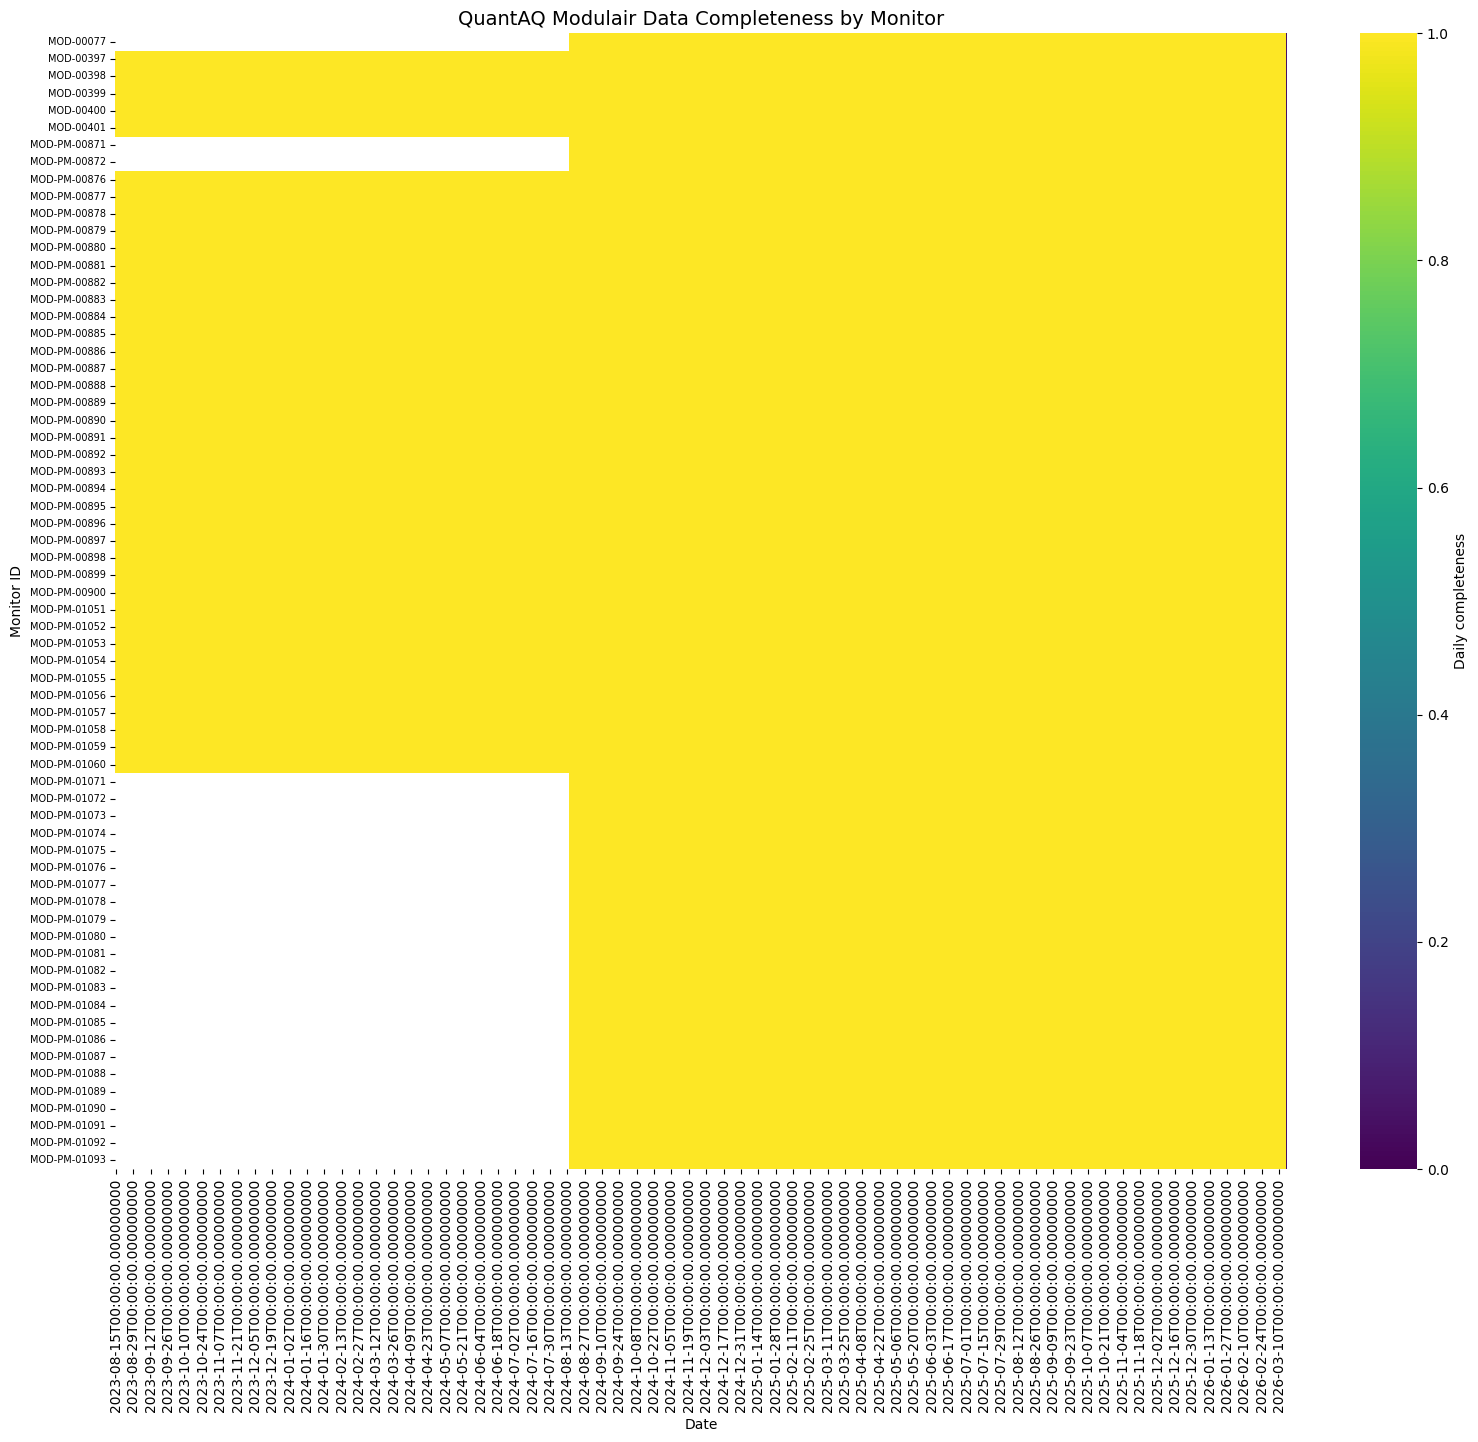

In [18]:
order = list(pivot_after.index)  # keep all 66 monitors
fig_height = max(12, len(order) * 0.22)

plt.figure(figsize=(16, fig_height))
ax = sns.heatmap(
    pivot_after.loc[order],
    cmap="viridis",
    vmin=0, vmax=1,
    cbar_kws={"label": "Daily completeness"},
    mask=pivot_after.loc[order] == 0  # hide background when completeness = 0
)

# show all y labels
ax.set_yticks(np.arange(len(order)) + 0.5)
ax.set_yticklabels(order, fontsize=7, rotation=0)

# style tweaks
ax.set_facecolor("white")  # make background white for masked cells
plt.title("QuantAQ Modulair Data Completeness by Monitor", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Monitor ID")
plt.tight_layout()
plt.show()


In [15]:
out_base = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/hourly_pm25_interpolated_fleetavg_xgb_20260330"

df_full.to_parquet(f"{out_base}.parquet", index=False)
df_full.to_csv(f"{out_base}.csv", index=False)

print(f"{out_base}.parquet")
print(f"{out_base}.csv")

/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/hourly_pm25_interpolated_fleetavg_xgb_20260330.parquet
/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/hourly_pm25_interpolated_fleetavg_xgb_20260330.csv


## Create daily summary too

In [19]:
daily_pm25 = (
    df_full
    .groupby(["monitor", "date"], as_index=False)
    .agg(
        n_hours_pm25=("pm25_filled", lambda x: x.notna().sum()),
        daily_mean_pm25=("pm25_filled", "mean"),
        n_imputed_hours=("pm25_was_imputed", "sum")
    )
    .query("n_hours_pm25 >= 18")
)

daily_pm25["pct_hours_present"] = daily_pm25["n_hours_pm25"] / 24
daily_pm25["pct_hours_imputed"] = daily_pm25["n_imputed_hours"] / daily_pm25["n_hours_pm25"]

In [20]:
daily_pm25

,monitor,date,n_hours_pm25,daily_mean_pm25,n_imputed_hours,pct_hours_present,pct_hours_imputed
0,MOD-00077,2024-08-15,24,15.800586,24,1.0,1.000000
1,MOD-00077,2024-08-16,24,15.800586,24,1.0,1.000000
2,MOD-00077,2024-08-17,24,15.268244,24,1.0,1.000000
3,MOD-00077,2024-08-18,24,14.493396,24,1.0,1.000000
4,MOD-00077,2024-08-19,24,14.626400,24,1.0,1.000000
...,...,...,...,...,...,...,...
52848,MOD-PM-01093,2026-03-11,24,10.212423,21,1.0,0.875000
52849,MOD-PM-01093,2026-03-12,24,10.311232,23,1.0,0.958333
52850,MOD-PM-01093,2026-03-13,24,10.688010,21,1.0,0.875000
52851,MOD-PM-01093,2026-03-14,24,10.239512,24,1.0,1.000000


In [21]:
out_base = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/daily_pm25_interpolated_fleetavg_xgb_20260330"

daily_pm25.to_parquet(f"{out_base}.parquet", index=False)
daily_pm25.to_csv(f"{out_base}.csv", index=False)

print(f"{out_base}.parquet")
print(f"{out_base}.csv")

/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/daily_pm25_interpolated_fleetavg_xgb_20260330.parquet
/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data_load_and_prep/interpolation/daily_pm25_interpolated_fleetavg_xgb_20260330.csv
